# Project 3: Global Mental Health Crisis Index 2026

## Scenario
The Global Mental Health Crisis Index 2026 is a cross-national dataset covering 92 countries across all six WHO regions, providing a comprehensive snapshot of the state of mental health worldwide as of 2025. It combines epidemiological, economic, policy, and digital behavior indicators into a single, analysis-ready file with no missing values.

- **Rows:** 92
- **Columns:** 29

## What’s Inside
Each row represents one country and includes 29 variables spanning:

- **Prevalence** — depression rate (%), anxiety rate (%), and estimated comorbidity
- **Crisis severity** — a composite mh_crisis_index score (0–100) and youth_mh_crisis_score
- **Healthcare capacity** — psychiatrists per 100k population, mental health budget as % of total health spending, per-capita mental health expenditure (USD)
- **Access & equity** — treatment gap (%), mental health policy/law existence (Yes/No)
- **Socioeconomic context** — GDP per capita, income group, population size
- **Digital environment** — average social media hours per day, internet penetration (%), social media mental health risk category
- **COVID-19 impact** — estimated % increase in mental health burden post-pandemic
- **System quality** — an aggregated mh_system_score reflecting infrastructure and investment

## Potential Use Cases
1. **Visualization & dashboards** — build regional heatmaps, scatter plots, or choropleth maps
2. **Social media & mental health** — explore the relationship between screen time and depression/anxiety rates
3. **COVID-19 aftermath** — analyze which regions saw the largest pandemic-era mental health surge
4. **Policy analysis** — examine the impact of mental health laws and budgets on treatment gaps
5. **Inequality research** — compare high-income vs. low-income country disparities in care access
6. **Clustering & segmentation** — group countries by mental health burden, system strength, or income level
7. **Regression & prediction** — model the crisis index from economic, digital, and policy variables

## Goal
- Showcase 5 of the above potential use cases.
- Bonus if you showcase 1 of the other two

---

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path


data_path = Path('./Global_Mental_Health_Crisis_Index_2026.csv')  
print(data_path.resolve())
print(data_path.exists())

alpha = 0.05

df = pd.read_csv(data_path)
df.sample(5)

C:\Users\xxslo\OneDrive\Desktop\AAI-bootcamp\student\C2\M4\Project-3\Global_Mental_Health_Crisis_Index_2026.csv
True


,country,iso3,region,income_group,depression_pct,anxiety_pct,suicide_rate_per100k,psychiatrists_per100k,mh_budget_pct_health,mh_spend_usd_per_capita,...,mh_crisis_index,total_affected_millions,psychiatrists_per_million,mh_investment_gap,social_media_mental_health_risk,depression_anxiety_comorbidity_est_pct,mh_system_score,income_group_code,data_year,data_source
84,Austria,AUT,Europe,High,4.8,5.1,14.2,22.30,7.6,108.0,...,41,0.90,223.0,0.160,Moderate (1.5-2.5h),2.40,75.4,4,2025,WHO Mental Health Atlas 2024 | GBD Study 2023 ...
21,South Africa,ZAF,Africa,Upper-Middle,4.9,6.2,9.8,0.30,0.9,1.8,...,70,6.65,3.0,0.078,Very High (>3.5h),2.45,7.2,3,2025,WHO Mental Health Atlas 2024 | GBD Study 2023 ...
39,Russia,RUS,Europe,Upper-Middle,5.2,4.6,26.5,10.70,2.5,16.0,...,61,14.09,107.0,0.138,Moderate (1.5-2.5h),2.60,34.8,3,2025,WHO Mental Health Atlas 2024 | GBD Study 2023 ...
0,Malawi,MWI,Africa,Low,3.3,4.5,6.5,0.02,0.8,0.1,...,87,1.59,0.2,0.078,Low (<1.5h),1.65,3.4,1,2025,WHO Mental Health Atlas 2024 | GBD Study 2023 ...
19,Myanmar,MMR,S-E Asia,Lower-Middle,3.6,4.7,9.0,0.20,1.2,0.2,...,70,4.48,2.0,0.106,High (2.5-3.5h),1.80,7.7,2,2025,WHO Mental Health Atlas 2024 | GBD Study 2023 ...


In [4]:
df.isnull().sum()

country                                   0
iso3                                      0
region                                    0
income_group                              0
depression_pct                            0
anxiety_pct                               0
suicide_rate_per100k                      0
psychiatrists_per100k                     0
mh_budget_pct_health                      0
mh_spend_usd_per_capita                   0
treatment_gap_pct                         0
social_media_hours_daily                  0
internet_penetration_pct                  0
gdp_per_capita_usd                        0
population_millions                       0
covid_mh_increase_pct                     0
youth_mh_crisis_score                     0
mh_policy_exists                          0
mh_law_exists                             0
mh_crisis_index                           0
total_affected_millions                   0
psychiatrists_per_million                 0
mh_investment_gap               

### Social media & mental health — explore the relationship between screen time and depression/anxiety rates

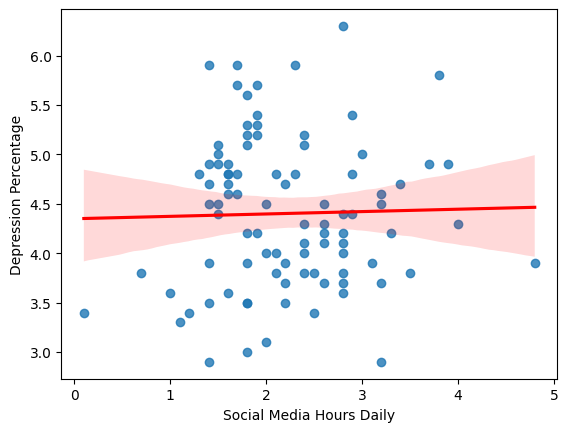

Pearson correlation: 0.03
p-value: 0.8120
Test result: Fail to Reject Null Hypothesis
 meaning there is no relationship between the social media hours daily and depression percentage


In [9]:
sns.regplot(
    data=df,
    x='social_media_hours_daily',
    y='depression_pct',
    line_kws={"color": "red"}
)
plt.xlabel('Social Media Hours Daily')
plt.ylabel('Depression Percentage')
plt.show()

from scipy.stats import pearsonr


corr, p_value = pearsonr(df['social_media_hours_daily'], df['depression_pct'])
print(f'Pearson correlation: {corr:.2f}')
print(f'p-value: {p_value:.4f}')
print('Test result:', 'Reject Null Hypothesis' if p_value < alpha else 'Fail to Reject Null Hypothesis\n meaning there is no relationship between the social media hours daily and depression percentage')


## COVID-19 aftermath — analyze which regions saw the largest pandemic-era mental health surge

region
Africa        74.071429
Americas      49.384615
E. Med        54.444444
Europe        36.656250
S-E Asia      58.000000
W. Pacific    45.076923
Name: covid_mh_increase_pct, dtype: float64


C:\Users\xxslo\AppData\Local\Temp\ipykernel_29348\1048011639.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=region_covid.values, y=region_covid.index, palette='viridis')


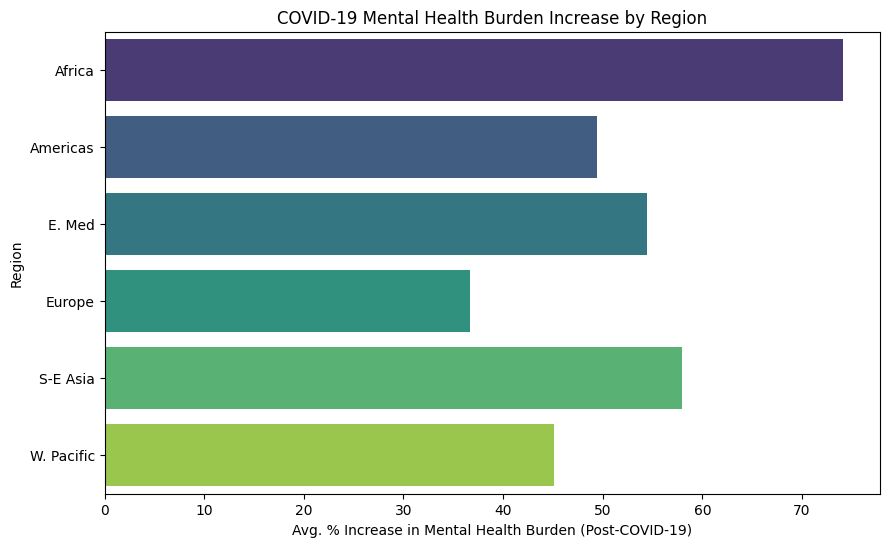

In [11]:
region_covid = df.groupby('region')['covid_mh_increase_pct'].mean()
print(region_covid)

plt.figure(figsize=(10,6))
sns.barplot(x=region_covid.values, y=region_covid.index, palette='viridis')
plt.xlabel('Avg. % Increase in Mental Health Burden (Post-COVID-19)')
plt.ylabel('Region')
plt.title('COVID-19 Mental Health Burden Increase by Region')
plt.show()

## Policy analysis — examine the impact of mental health laws and budgets on treatment gaps

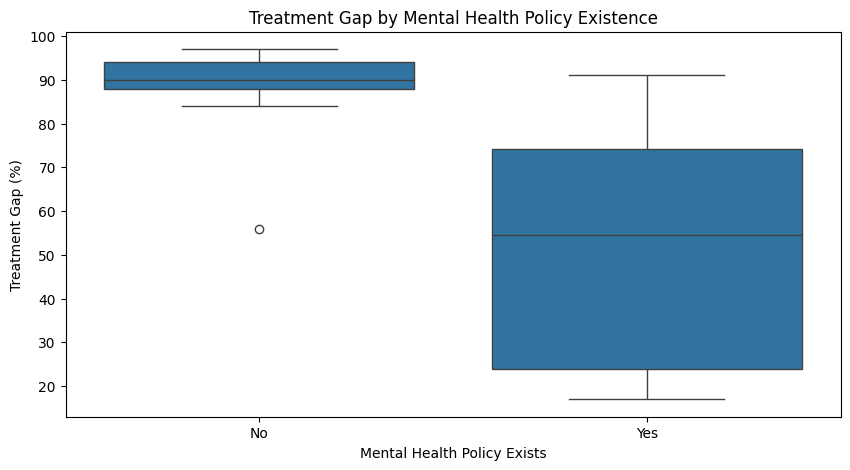

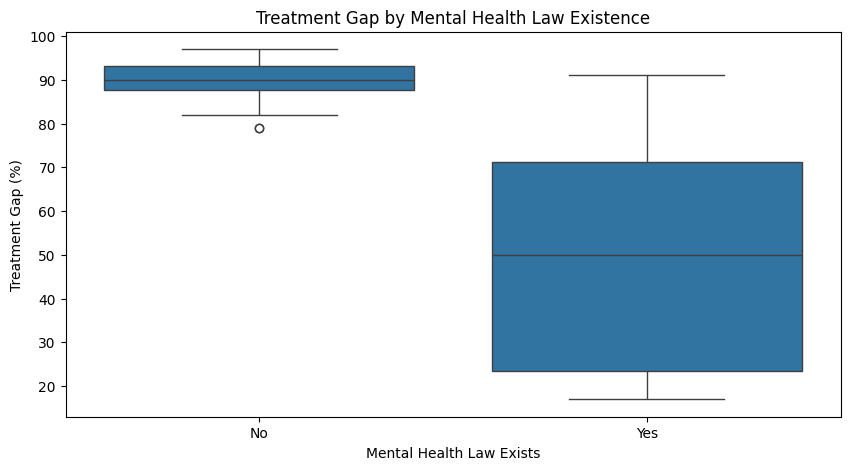

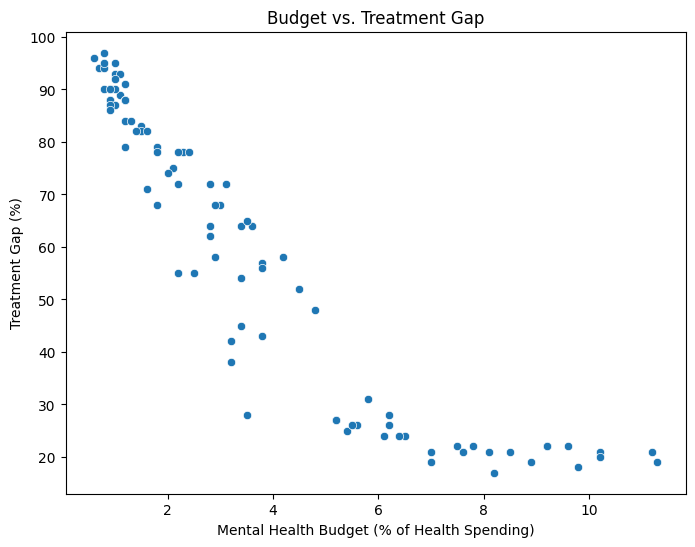

Test result: Reject Null Hypothesis


In [13]:
plt.figure(figsize=(10,5))
sns.boxplot(x='mh_policy_exists', y='treatment_gap_pct', data=df)
plt.xlabel('Mental Health Policy Exists')
plt.ylabel('Treatment Gap (%)')
plt.title('Treatment Gap by Mental Health Policy Existence')
plt.show()

plt.figure(figsize=(10,5))
sns.boxplot(x='mh_law_exists', y='treatment_gap_pct', data=df)
plt.xlabel('Mental Health Law Exists')
plt.ylabel('Treatment Gap (%)')
plt.title('Treatment Gap by Mental Health Law Existence')
plt.show()

plt.figure(figsize=(8,6))
sns.scatterplot(x='mh_budget_pct_health', y='treatment_gap_pct', data=df)
plt.xlabel('Mental Health Budget (% of Health Spending)')
plt.ylabel('Treatment Gap (%)')
plt.title('Budget vs. Treatment Gap')
plt.show()

from scipy.stats import pearsonr
corr, p_value = pearsonr(df['mh_budget_pct_health'], df['treatment_gap_pct'])
print('Test result:', 'Reject Null Hypothesis' if p_value < alpha else 'Fail to Reject Null Hypothesis\n meaning there is no relationship between the mental health budget percentage and treatment gap')

## Inequality research — compare high-income vs. low-income country disparities in care access

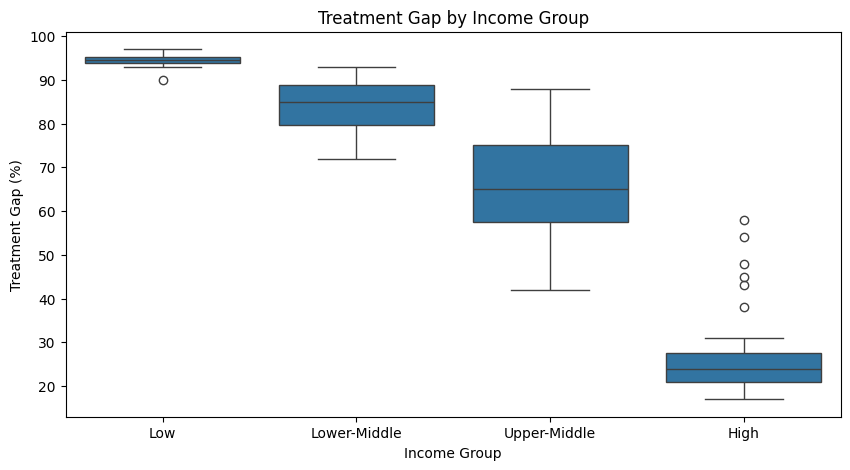

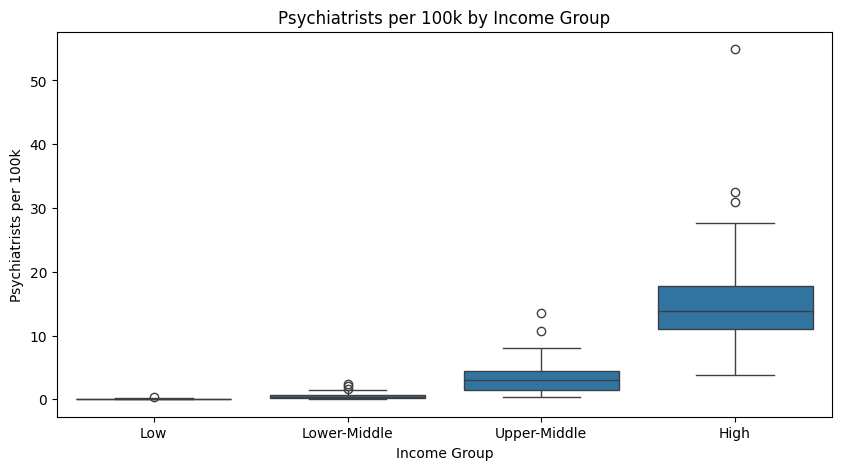

In [14]:
plt.figure(figsize=(10,5))
sns.boxplot(x='income_group', y='treatment_gap_pct', data=df, order=['Low', 'Lower-Middle', 'Upper-Middle', 'High'])
plt.xlabel('Income Group')
plt.ylabel('Treatment Gap (%)')
plt.title('Treatment Gap by Income Group')
plt.show()

plt.figure(figsize=(10,5))
sns.boxplot(x='income_group', y='psychiatrists_per100k', data=df, order=['Low', 'Lower-Middle', 'Upper-Middle', 'High'])
plt.xlabel('Income Group')
plt.ylabel('Psychiatrists per 100k')
plt.title('Psychiatrists per 100k by Income Group')
plt.show()